## Problem 1:
In Problem 7.1, the increased load at each increment is allocated to slack bus 1. In practice, the AGC system allocates it through the area control error, etc. As an alternative, consider allocating the increased load in proportion to the inertias of the machine, that is, ΔPL5 is allocated to buses 2 and 3 as P^{k+1}\_{G2} = P^k\_{G2} + H2/HT  ΔPL5  and P^{k+1}\_{G3} = P^k\_{G3} + H3/HT  ΔPL5, where P^k_{G2} and P^k_{G3} are the generator powers before  the load is increased and HT = H1 + H2 + H3. Again draw the PV curve

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


In [2]:

# Y_bus matrix from Table 7.2
Y_N = np.array([
    [-17.361j, 0, 0, 17.361j, 0, 0, 0, 0, 0],
    [0, -16j, 0, 0, 0, 0, 16j, 0, 0],
    [0, 0, -17.065j, 0, 0, 0, 0, 0, 17.065j],
    [17.361j, 0, 0, 3.307-39.309j, -1.365+11.604j, -1.942+10.511j, 0, 0, 0],
    [0, 0, 0, -1.365+11.604j, 2.553-17.338j, 0, -1.188+5.975j, 0, 0],
    [0, 0, 0, -1.942+10.511j, 0, 3.224-15.841j, 0, 0, -1.282+5.588j],
    [0, 16j, 0, 0, -1.188+5.975j, 0, 2.805-35.446j, -1.617+13.698j, 0],
    [0, 0, 0, 0, 0, 0, -1.617+13.698j, 2.772-23.303j, -1.155+9.784j],
    [0, 0, 17.065j, 0, 0, -1.282+5.588j, 0, -1.155+9.784j, 2.437-32.154j]
], dtype=complex)

# Verification: Print the shape to ensure it's 9x9
print(f"Matrix Shape: {Y_N.shape}")

N = Y_N.shape[0]
G = 3

PL = np.zeros(N)  # Load active power (P) in per unit
QL = np.zeros(N)  # Load reactive power (Q) in per unit

PL[4] = 1.25
QL[4] = 0.5
PL[5] = 0.9
QL[5] = 0.3
PL[7] = 1.00
QL[7] = 0.35

H1 = 23.64
H2 = 6.4
H3 = 3.01
HT = H1 + H2 + H3

v1 = 1.04
v2 = 1.025
v3 = 1.025

Pg = np.zeros(N)
Pg[0] = 0.716
Pg[1] = 1.63
Pg[2] = 0.85

alpha = np.zeros(N)
alpha[0] = H1 / HT
alpha[1] = H2 / HT
alpha[2] = H3 / HT

def x_interface(x):
    delta_p = x[0]
    thetas = np.hstack((0, x[1:N]))
    voltages = np.hstack((v1, v2, v3, x[N:]))
    return delta_p, thetas, voltages

# Flat start
x = np.zeros(1 + N-1 + N-G)
x[N:] = 1.0  # Voltage magnitudes
delta_p, thetas, voltages = x_interface(x)
print("Initial delta_p:", delta_p)
print("Initial thetas:", thetas.flatten())
print("Initial voltages:", voltages.flatten())


Matrix Shape: (9, 9)
Initial delta_p: 0.0
Initial thetas: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Initial voltages: [1.04  1.025 1.025 1.    1.    1.    1.    1.    1.   ]


In [3]:
def f(x):
    # Test function to verify Newton method implementation
    A = np.array(((2, 1), (1, 2)))
    b = np.array((-1, 1))
    return A @ x - b

def jacobian(f, x):
    N = len(x)
    J = np.zeros((N, N))
    h = 1e-7
    for i in range(N):
        dx = np.zeros(N)
        dx[i] = h/2

        J[:, i] = (f(x + dx) - f(x-dx)) / h

    
    return J

def newton(x0, f, iterations=10):
    x = x0.copy()
    for i in range(iterations):
        try:
            # print(f"Iteration {i}, x: {x}, f(x): {f(x)}")
            x = x - np.linalg.solve(jacobian(f, x), f(x))
        except np.linalg.LinAlgError:
            print("Jacobian is singular at iteration", i)
            break
    return x

x0 = np.zeros(2)
x_star = newton(x0, f)
print("Solution:", x_star)
print("f(Solution):", f(x_star))

Solution: [-1.  1.]
f(Solution): [0. 0.]


In [4]:
def fp(x):
    res = np.zeros(N)
    delta_p, thetas, voltages = x_interface(x)
    for i in range(N):
        res[i] = Pg[i] + alpha[i] * delta_p - PL[i] - voltages[i] * np.real(np.sum(Y_N[i, :] * voltages * np.exp(1j * (thetas - thetas[i]))))
    return res

def fq(x):
    res = np.zeros(N-G)
    delta_p, thetas, voltages = x_interface(x)
    for i in range(len(res)):
        bus_idx = i + G
        res[i] = - QL[bus_idx] +  voltages[bus_idx] * np.imag(np.sum(Y_N[bus_idx, :] * voltages * np.exp(1j * (thetas - thetas[bus_idx]))))
    return res


def f_total(x):
    res = np.zeros_like(x)
    res[:N] = fp(x)
    res[N:] = fq(x)
    return res

In [5]:
res = newton(x, f_total, iterations=5)
delta_p, thetas, voltages = x_interface(res)

print("Delta P:", delta_p)
print("Thetas:", thetas)
print("Voltages:", voltages)

Delta P: 0.00042658983772685854
Thetas: [ 0.          0.16200446  0.08144632 -0.0386853  -0.06960817 -0.06434753
  0.06495123  0.01272473  0.03435372]
Voltages: [1.04       1.025      1.025      1.02577559 0.99560718 1.01263492
 1.0257411  1.01585385 1.03232528]


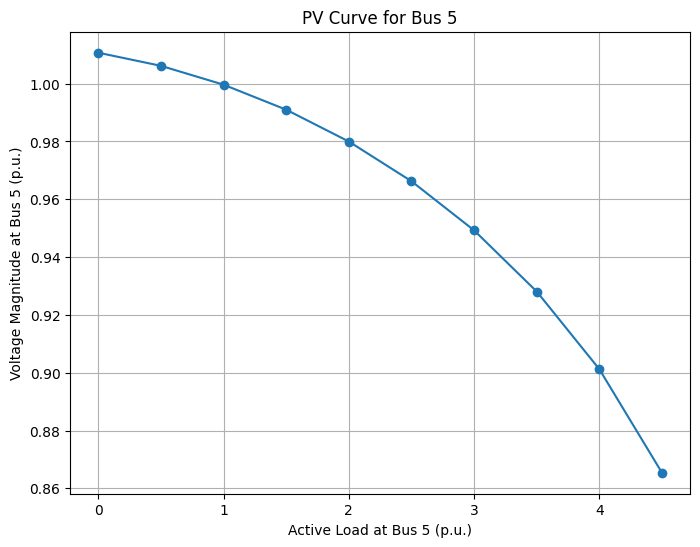

In [6]:

bus_5_loads = np.arange(0, 4.5 + 0.5, 0.5)
voltage_magnitudes = []

for load in bus_5_loads:
    PL[4] = load
    res = newton(x, f_total, iterations=10)
    delta_p, thetas, voltages = x_interface(res)
    voltage_magnitudes.append(voltages[4])  # Voltage magnitude at bus 5

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.plot(bus_5_loads, voltage_magnitudes, marker='o')
axs.set_title('PV Curve for Bus 5')
axs.set_xlabel('Active Load at Bus 5 (p.u.)')
plt.ylabel('Voltage Magnitude at Bus 5 (p.u.)')
plt.grid()
plt.show()

## Problem 2
Use the following algorithms to solve the initial value problem:

\dot{x}_1 = -2x_2 + 2t^2

\dot{x}_2 = 0.5x_1 + 2t

x_1(0) = -4

x_2(0) = 0

on the interval 0 ≤ t ≤ 5 with a fixed integration step of 0.25 seconds.

(a) Backward Euler

(b) Forward Euler

(c) Trapezoidal

(d) Fourth-order Runge-Kutta

Compare the numerical solutions to the exact one:

x1(t) = −4 cos(t)

x2(t) = −2 sin(t) + t^2

(2, 21)


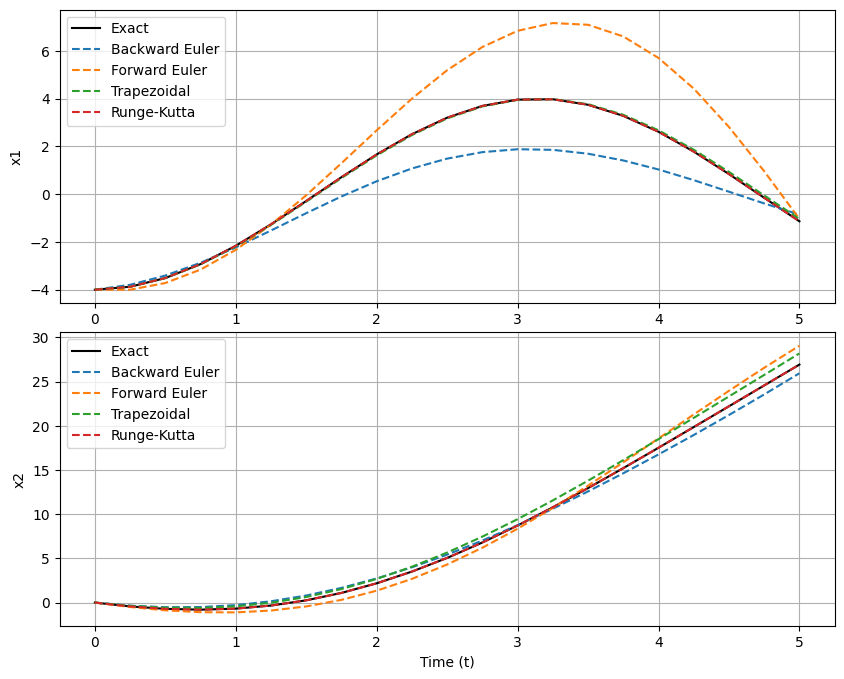

In [7]:
x0 = np.array((-4, 0))

def fx(x, t):
    dx1_dt = -2*x[1] + 2*t**2
    dx2_dt = 0.5*x[0] + 2*t

    return np.array([dx1_dt, dx2_dt])

def x(t):
    x1 = -4 * np.cos(t)
    x2 = -2 * np.sin(t) + t**2
    # print(x1.shape, x2.shape)
    return np.vstack((x1, x2))

ts = np.arange(0, 5.25, 0.25)
xs_BE = np.zeros((2, len(ts)))
xs_FE = np.zeros((2, len(ts)))
xs_TR = np.zeros((2, len(ts)))
XS_RK = np.zeros((2, len(ts)))

xs_BE[:, 0] = x0
xs_FE[:, 0] = x0
xs_TR[:, 0] = x0
XS_RK[:, 0] = x0

exact_solution = x(ts)
print(exact_solution.shape)

# Backward Euler
for i in range(1, len(ts)):
    t = ts[i]
    x_prev = xs_BE[:, i-1]
    # Implicit method: Solve for x using Newton's method
    def g(x):
        return x - x_prev - fx(x, t) * (ts[i] - ts[i-1])
    
    xs_BE[:, i] = newton(x_prev, g)

# Forward Euler
for i in range(1, len(ts)):
    t = ts[i-1]
    xs_FE[:, i] = xs_FE[:, i-1] + fx(xs_FE[:, i-1], t) * (ts[i] - ts[i-1])

# Trapezoidal Rule
for i in range(1, len(ts)):
    t = ts[i]
    x_prev = xs_TR[:, i-1]
    
    def g(x):
        return x - x_prev - 0.5 * (fx(x_prev, t) + fx(x, t)) * (ts[i] - ts[i-1])
    
    xs_TR[:, i] = newton(x_prev, g)

# Runge-Kutta 4th order
for i in range(1, len(ts)):
    t = ts[i-1]
    x_prev = XS_RK[:, i-1]
    
    k1 = fx(x_prev, t)
    k2 = fx(x_prev + 0.5 * k1 * (ts[i] - ts[i-1]), t + 0.5 * (ts[i] - ts[i-1]))
    k3 = fx(x_prev + 0.5 * k2 * (ts[i] - ts[i-1]), t + 0.5 * (ts[i] - ts[i-1]))
    k4 = fx(x_prev + k3 * (ts[i] - ts[i-1]), t + (ts[i] - ts[i-1]))
    
    XS_RK[:, i] = x_prev + (k1 + 2*k2 + 2*k3 + k4) * (ts[i] - ts[i-1]) / 6

# Plot the same data as above using subplots for better visualization
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 1, hspace=0.1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax1.plot(ts, exact_solution[0], label='Exact', color='black')
ax1.plot(ts, xs_BE[0], label='Backward Euler', linestyle='--')
ax1.plot(ts, xs_FE[0], label='Forward Euler', linestyle='--')
ax1.plot(ts, xs_TR[0], label='Trapezoidal', linestyle='--')
ax1.plot(ts, XS_RK[0], label='Runge-Kutta', linestyle='--')
# ax1.set_title('x1(t)')
ax1.set(ylabel='x1')
ax1.legend()
ax1.grid()

ax2.plot(ts, exact_solution[1], label='Exact', color='black')
ax2.plot(ts, xs_BE[1], label='Backward Euler', linestyle='--')
ax2.plot(ts, xs_FE[1], label='Forward Euler', linestyle='--')
ax2.plot(ts, xs_TR[1], label='Trapezoidal', linestyle='--')
ax2.plot(ts, XS_RK[1], label='Runge-Kutta', linestyle='--')
# ax2.set_title('x2(t)')
ax2.set(xlabel='Time (t)', ylabel='x2')
ax2.legend()
ax2.grid()
plt.show()


## Problem 3
FE vs BE for stiff systems


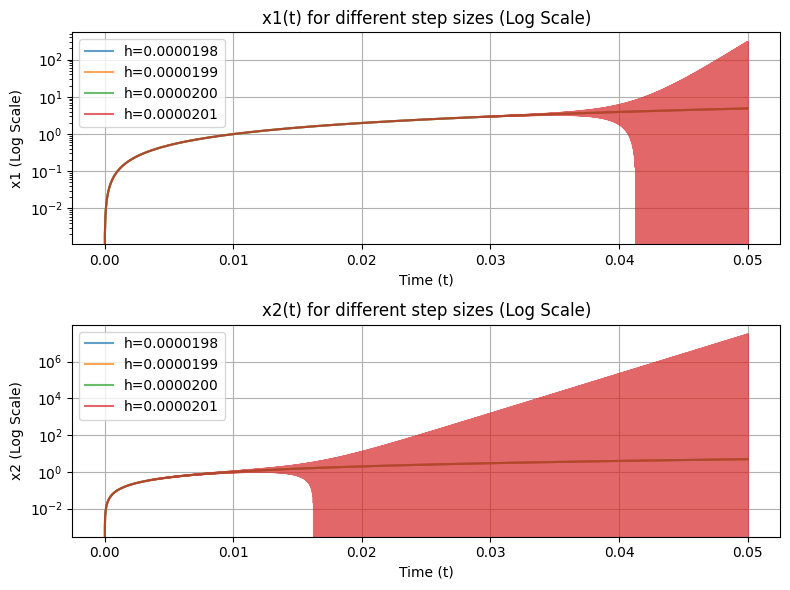

In [8]:
def q3_f(x):
    # x1_dot = -2x1 + x2 + 100
    # x2_dot = 10e4 x1 - 10e4 x2 + 50

    dx1_dt = -2*x[0] + x[1] + 100
    dx2_dt = 10e4 * x[0] - 10e4 * x[1] + 50
    return np.array([dx1_dt, dx2_dt])

x0 = np.array((0, 0))
hs = np.arange(0.0000198, 0.0000201, 0.0000001)

def euler(h, x0, f, T=0.05):
    ts = np.arange(0, T + h, h)
    xs = np.zeros((2, len(ts)))
    xs[:, 0] = x0
    for i in range(1, len(ts)):
        t = ts[i-1]
        xs[:, i] = xs[:, i-1] + f(xs[:, i-1]) * h
    return ts, xs

tss = []
xss = []

for h in hs:
    ts, xs = euler(h, x0, q3_f)
    tss.append(ts)
    xss.append(xs)

fig3, axs3 = plt.subplots(2, 1, figsize=(8, 6))
for i, h in enumerate(hs):
    axs3[0].semilogy(tss[i], xss[i][0], label=f'h={h:.7f}', alpha=0.7)
axs3[0].set_title('x1(t) for different step sizes (Log Scale)')
axs3[0].set_xlabel('Time (t)')
axs3[0].set_ylabel('x1 (Log Scale)')
axs3[0].legend()
axs3[0].grid()

for i, h in enumerate(hs):
    axs3[1].semilogy(tss[i], xss[i][1], label=f'h={h:.7f}', alpha=0.7)
axs3[1].set_title('x2(t) for different step sizes (Log Scale)')
axs3[1].set_xlabel('Time (t)')
axs3[1].set_ylabel('x2 (Log Scale)')
axs3[1].legend()
axs3[1].grid()
plt.tight_layout()
plt.show()




In [9]:
h_max = 0.00002
print(f"Maximum stable step size: {h_max}")

Maximum stable step size: 2e-05


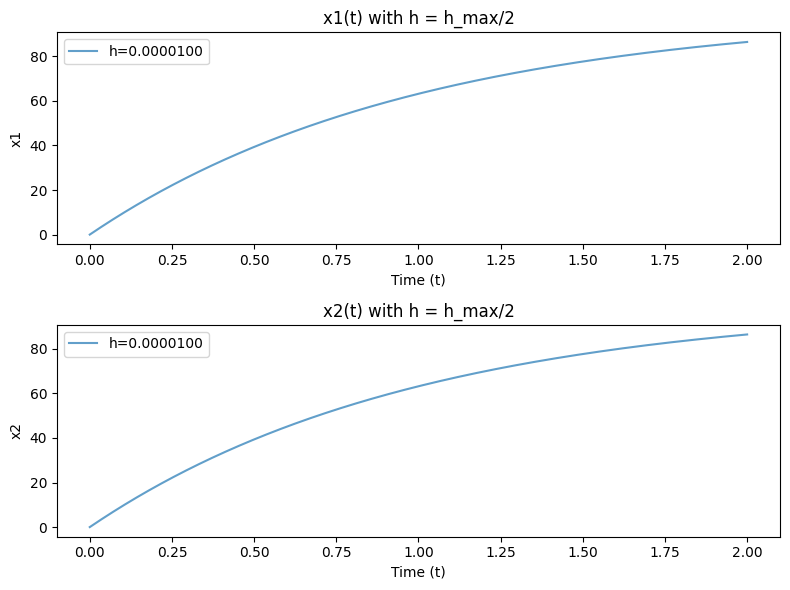

In [10]:
ts_half, xs_half = euler(h_max/2, x0, q3_f, T=2.0)

fig4, axs4 = plt.subplots(2, 1, figsize=(8, 6))
axs4[0].plot(ts_half, xs_half[0], label=f'h={h_max/2:.7f}', alpha=0.7)
axs4[0].set_title('x1(t) with h = h_max/2')
axs4[0].set_xlabel('Time (t)')
axs4[0].set_ylabel('x1')
axs4[0].legend()

axs4[1].plot(ts_half, xs_half[1], label=f'h={h_max/2:.7f}', alpha=0.7)
axs4[1].set_title('x2(t) with h = h_max/2')
axs4[1].set_xlabel('Time (t)')
axs4[1].set_ylabel('x2')
axs4[1].legend()
plt.tight_layout()

plt.show()

C:\Users\ryanalizadeh\AppData\Local\Temp\ipykernel_21340\2217088052.py:6: RuntimeWarning: overflow encountered in scalar multiply
  dx2_dt = 10e4 * x[0] - 10e4 * x[1] + 50
C:\Users\ryanalizadeh\AppData\Local\Temp\ipykernel_21340\2217088052.py:18: RuntimeWarning: invalid value encountered in add
  xs[:, i] = xs[:, i-1] + f(xs[:, i-1]) * h


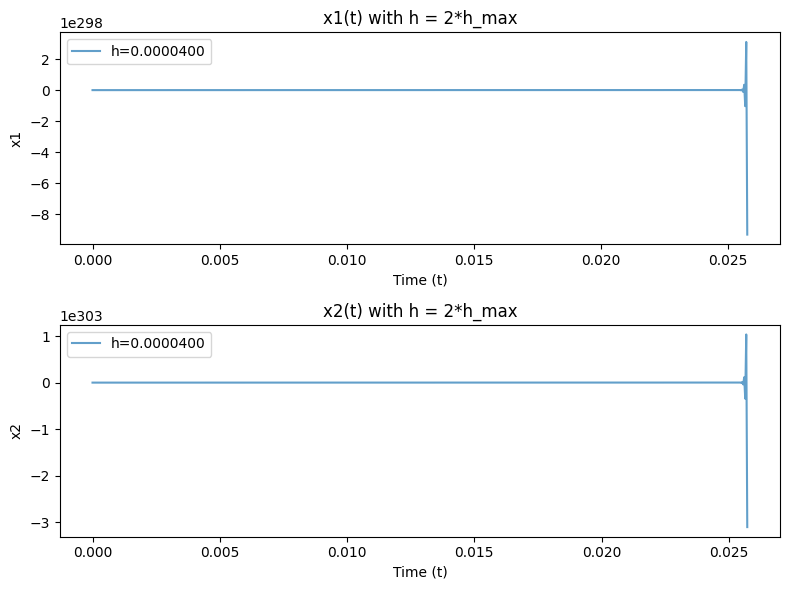

In [11]:
ts_double, xs_double = euler(h_max*2, x0, q3_f, T=2.0)

fig4, axs4 = plt.subplots(2, 1, figsize=(8, 6))
axs4[0].plot(ts_double, xs_double[0], label=f'h={2*h_max:.7f}', alpha=0.7)
axs4[0].set_title('x1(t) with h = 2*h_max')
axs4[0].set_xlabel('Time (t)')
axs4[0].set_ylabel('x1')
axs4[0].legend()

axs4[1].plot(ts_double, xs_double[1], label=f'h={2*h_max:.7f}', alpha=0.7)
axs4[1].set_title('x2(t) with h = 2*h_max')
axs4[1].set_xlabel('Time (t)')
axs4[1].set_ylabel('x2')
axs4[1].legend()
plt.tight_layout()

plt.show()

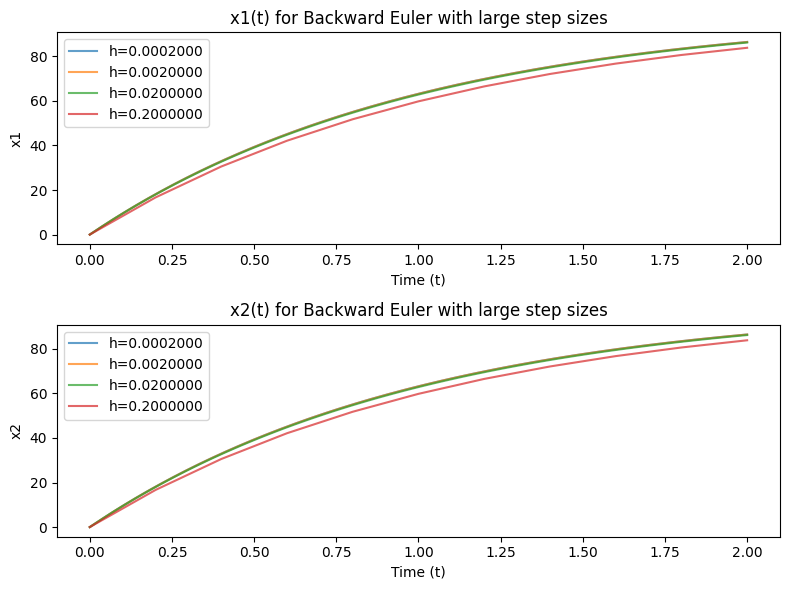

In [12]:
# Now use backward Euler with h = 10hmax, h = 100hmax, h = 1000hmax, and h = 10000hmax and plot the results

def backward_euler(h, x0, f):
    ts = np.arange(0, 2.0 + h, h)
    xs = np.zeros((2, len(ts)))
    xs[:, 0] = x0
    for i in range(1, len(ts)):
        t = ts[i]
        x_prev = xs[:, i-1]
        
        def g(x):
            return x - x_prev - f(x) * h
        
        xs[:, i] = newton(x_prev, g)
    
    return ts, xs

h_values = [10*h_max, 100*h_max, 1000*h_max, 10000*h_max]
fig5, axs5 = plt.subplots(2, 1, figsize=(8, 6))
ts_bes = []
xs_bes = []

for h in h_values:
    ts_be, xs_be = backward_euler(h, x0, q3_f)
    ts_bes.append(ts_be)
    xs_bes.append(xs_be)
    axs5[0].plot(ts_be, xs_be[0], label=f'h={h:.7f}', alpha=0.7)
    axs5[1].plot(ts_be, xs_be[1], label=f'h={h:.7f}', alpha=0.7)
axs5[0].set_title('x1(t) for Backward Euler with large step sizes')
axs5[0].set_xlabel('Time (t)')
axs5[0].set_ylabel('x1')
axs5[0].legend()
axs5[1].set_title('x2(t) for Backward Euler with large step sizes')
axs5[1].set_xlabel('Time (t)')
axs5[1].set_ylabel('x2')
axs5[1].legend()
plt.tight_layout()
plt.show()

## Problem 4:
Simulate the 3-bus system with distributed slack with 

- R12 = 0.01
- R23 = 0.02
- R13 = 0.01
- X12 = 0.08
- X23 = 0.161
- X13 = 0.092
- ysh12 = j0.088
- ysh23 = j0.153
- ysh13 = j0.079

Generator 1 params
- H1 = 8
- D1 = 0
- RD1 = 0.04
- X1_p = 0.0608

and Generator 2 params
- H2 = 3.01
- D2 = 0
- RD2 = 0.04
- X2_p = 0.1813

In [13]:
omega_s = 2 * np.pi * 60

H1 = 8
D1 = 0
RD1 = 0.04
X1_p = 0.0608

H2 = 3.01
D2 = 0
RD2 = 0.04
X2_p = 0.1813

Tsv1 = 2
Tsv2 = 2

R12 = 0.01
R23 = 0.02
R13 = 0.01
X12 = 0.085
X23 = 0.161
X13 = 0.092
ysh12 = 0.088j
ysh23 = 0.153j
ysh13 = 0.079j

V10 = 1.04
theta10 = 0.0
V20 = 1.025
theta20 = -0.148 * np.pi / 180
V30 = 0.994
theta30 = -7.65 * np.pi / 180

S10 = 1.597 + 0.452j
S20 = 0.791 - 0.279j
S30 = -2.35 - 0.5j

PC1 = np.real(S10)
PC2 = np.real(S20)

I10 = np.conj(S10 / (V10 * np.exp(1j * theta10)))
I20 = np.conj(S20 / (V20 * np.exp(1j * theta20)))
I30 = np.conj(S30 / (V30 * np.exp(1j * theta30)))

E1 = V10 * np.exp(1j * theta10) + 1j*X1_p * I10
E2 = V20 * np.exp(1j * theta20) + 1j*X2_p * I20

E10 = np.abs(E1)
E20 = np.abs(E2)

delta10 = np.angle(E1)
delta20 = np.angle(E2)

omega10 = omega_s
omega20 = omega_s

Ybus = np.array([
    [1/(R12 + 1j*X12) + 1/(R13 + 1j*X13) + ysh12 + ysh13, -1/(R12 + 1j*X12), -1/(R13 + 1j*X13)],
    [-1/(R12 + 1j*X12), 1/(R12 + 1j*X12) + 1/(R23 + 1j*X23) + ysh12 + ysh23, -1/(R23 + 1j*X23)],
    [-1/(R13 + 1j*X13), -1/(R23 + 1j*X23), 1/(R13 + 1j*X13) + 1/(R23 + 1j*X23) + ysh13 + ysh23]
], dtype=complex)

def unpack_x(x):
    delta1 = x[0]
    omega1 = x[1]
    Tm1 = x[2]
    delta2 = x[3]
    omega2 = x[4]
    Tm2 = x[5]

    return delta1, omega1, Tm1, delta2, omega2, Tm2

def unpack_y(y):
    V1 = y[0]
    theta1 = y[1]
    V2 = y[2]
    theta2 = y[3]
    V3 = y[4]
    theta3 = y[5]

    return V1, theta1, V2, theta2, V3, theta3

def model_AE(x, y, t, PL3, QL3):
    delta1, omega1, Tm1, delta2, omega2, Tm2 = unpack_x(x)
    V1, theta1, V2, theta2, V3, theta3 = unpack_y(y)

    ret = np.zeros_like(y)
    V1C = V1 * np.exp(1j * theta1)
    V2C = V2 * np.exp(1j * theta2)
    V3C = V3 * np.exp(1j * theta3)

    I1 = (E10 * np.exp(1j * (delta1 + delta10)) - V1C) / (1j*X1_p)
    I2 = (E20 * np.exp(1j * (delta2 + delta20)) - V2C) / (1j*X2_p)

    # Network eqs
    current1 = I1 - Ybus[0, 0] * V1C - Ybus[0, 1] * V2C - Ybus[0, 2] * V3C
    current2 = I2 - Ybus[1, 0] * V1C - Ybus[1, 1] * V2C - Ybus[1, 2] * V3C

    power3 = (PL3 + 1j*QL3) - V3C * np.conj(Ybus[2, 0] * V1C + Ybus[2, 1] * V2C + Ybus[2, 2] * V3C)

    # print("Current1:", current1)
    # print("Current2:", current2)
    # print("Power3:", power3)

    ret[0] = np.real(current1)
    ret[1] = np.imag(current1)
    ret[2] = np.real(current2)
    ret[3] = np.imag(current2)
    ret[4] = np.real(power3)
    ret[5] = np.imag(power3)

    return ret

def model_dynamics(x, y, t):
    delta1, omega1, Tm1, delta2, omega2, Tm2 = unpack_x(x)
    V1, theta1, V2, theta2, V3, theta3 = unpack_y(y)

    V1C = V1 * np.exp(1j * theta1)
    V2C = V2 * np.exp(1j * theta2)

    I1 = (E10 * np.exp(1j * (delta1 + delta10)) - V1C) / (1j*X1_p)
    I2 = (E20 * np.exp(1j * (delta2 + delta20)) - V2C) / (1j*X2_p)

    ret = np.zeros_like(x)

    delta1_dot = omega1 - omega_s
    omega1_dot = (omega_s/(2*H1)) * (Tm1 - np.real(E10 * np.exp(1j * (delta1 + delta10)) * np.conj(I1)) - D1 * (omega1/omega_s - 1))
    Tm1_dot = (1 / Tsv1) * (-Tm1 + PC1 - 1/RD1 * (omega1/omega_s - 1))
    delta2_dot = omega2 - omega_s
    omega2_dot = (omega_s/(2*H2)) * (Tm2 - np.real(E20 * np.exp(1j * (delta2 + delta20)) * np.conj(I2)) - D2 * (omega2/omega_s - 1))
    Tm2_dot = (1 / Tsv2) * (-Tm2 + PC2 - 1/RD2 * (omega2/omega_s - 1))

    ret[0] = delta1_dot
    ret[1] = omega1_dot
    ret[2] = Tm1_dot
    ret[3] = delta2_dot
    ret[4] = omega2_dot
    ret[5] = Tm2_dot
    return ret

In [14]:
# Simultaneous implicit solution
h = 0.01
T = 30.0

ts = np.arange(0, T + h, h)
xs = np.zeros((6, len(ts)))
ys = np.zeros((6, len(ts)))

# y: V1, theta1, V2, theta2, V3, theta3
# x: delta1, omega1, Tm1, delta2, omega2, Tm2

xs[:, 0] = np.array((0, omega10, PC1, 0, omega20, PC2))
ys[:, 0] = np.array((V10, theta10, V20, theta20, V30, theta30))

# print("Initial x:", xs[:, 0])
# print("Initial y:", ys[:, 0])

P_init = np.real(S30)
Q_init = np.imag(S30)

P_post = -2.45
Q_post = Q_init

for i, t in enumerate(ts[1:], start=1):
    t = ts[i]
    x_prev = xs[:, i-1]
    y_prev = ys[:, i-1]

    P = P_init if t < 0.5 else P_post
    Q = Q_init if t < 0.5 else Q_post

    def g(z):
        x = z[:6]
        y = z[6:]
        res = np.zeros(12)
        res[:6] = model_AE(x, y, t, PL3=P, QL3=Q)
        res[6:] = (x - x_prev - (model_dynamics(x, y, t) + model_dynamics(x_prev, y_prev, t)) * h/2)
        return res
    
    z0 = np.hstack((x_prev, y_prev))
    z_next = newton(z0, g)
    xs[:, i] = z_next[:6]
    ys[:, i] = z_next[6:]

In [15]:
# Determine theoretical power outputs and frequency deviations
delta_omega_theoretical = (P_post - P_init) / (1/RD1 + 1/RD2 + D1 + D2)
ss_omega_theoretical = omega_s * (1 + delta_omega_theoretical)

P1_ss_theoretical = PC1 - (1/RD1 + D1) * delta_omega_theoretical
P2_ss_theoretical = PC2 - (1/RD2 + D2) * delta_omega_theoretical

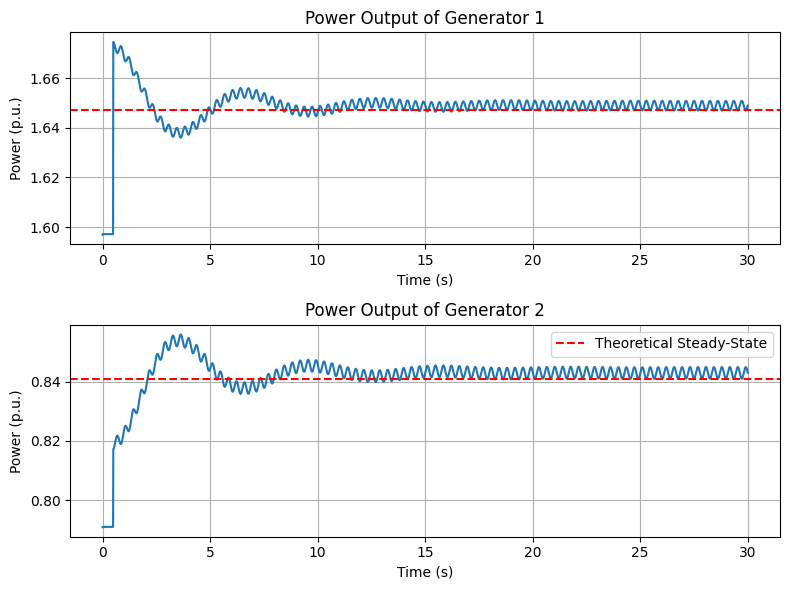

In [16]:
# Determine power outputs
P1_out = -np.real(E10 * np.exp(1j * (xs[0, :] + delta10)) * np.conj((ys[0, :] * np.exp(1j * ys[1, :]) - E10 * np.exp(1j * (xs[0, :] + delta10))) / (1j*X1_p)))
P2_out = -np.real(E20 * np.exp(1j * (xs[3, :] + delta20)) * np.conj((ys[2, :] * np.exp(1j * ys[3, :]) - E20 * np.exp(1j * (xs[3, :] + delta20))) / (1j*X2_p)))

# Plotting results
fig9, ax9 = plt.subplots(2, 1, figsize=(8, 6))
ax9[0].plot(ts, P1_out)
ax9[0].axhline(P1_ss_theoretical, color='red', linestyle='--', label='Theoretical Steady-State')
ax9[0].set_title('Power Output of Generator 1')
ax9[0].set_xlabel('Time (s)')
ax9[0].set_ylabel('Power (p.u.)')
ax9[0].grid()
ax9[1].plot(ts, P2_out)
ax9[1].axhline(P2_ss_theoretical, color='red', linestyle='--', label='Theoretical Steady-State')
ax9[1].set_title('Power Output of Generator 2')
ax9[1].set_xlabel('Time (s)')
ax9[1].set_ylabel('Power (p.u.)')
ax9[1].legend()
ax9[1].grid()
plt.tight_layout()
plt.show()

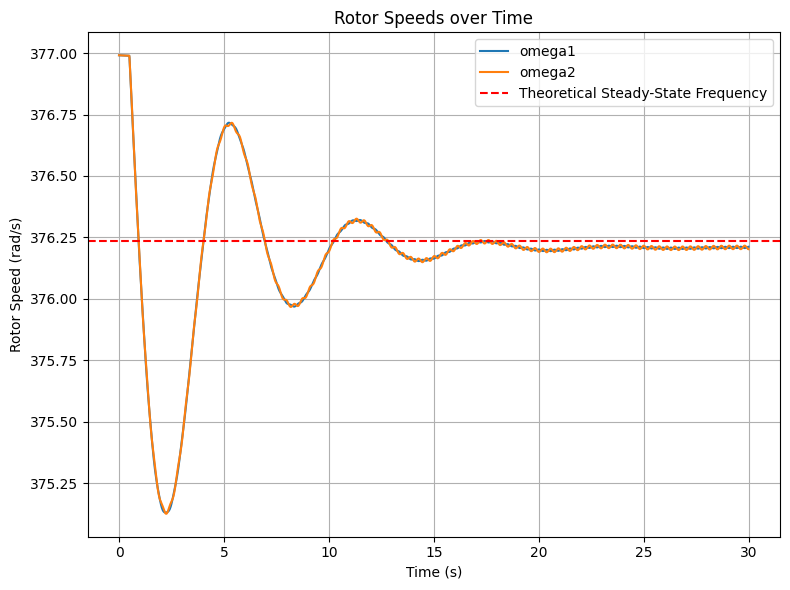

In [17]:
fig1, ax10 = plt.subplots(1, 1, figsize=(8, 6))
ax10.plot(ts, xs[1, :], label='omega1')
ax10.plot(ts, xs[4, :], label='omega2')
ax10.axhline(ss_omega_theoretical, color='red', linestyle='--', label='Theoretical Steady-State Frequency')
ax10.set_title('Rotor Speeds over Time')
ax10.set_xlabel('Time (s)')
ax10.set_ylabel('Rotor Speed (rad/s)')
ax10.legend()
ax10.grid()
plt.tight_layout()
plt.show()

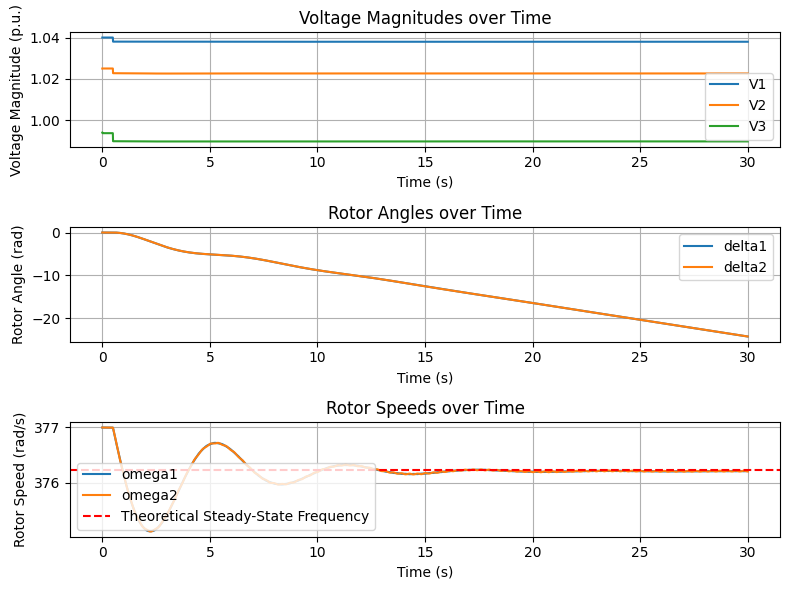

In [18]:
# Plot the results
fig6, axs6 = plt.subplots(3, 1, figsize=(8, 6))
axs6[0].plot(ts, ys[0, :], label='V1')
axs6[0].plot(ts, ys[2, :], label='V2')
axs6[0].plot(ts, ys[4, :], label='V3')
axs6[0].set_title('Voltage Magnitudes over Time')
axs6[0].set_xlabel('Time (s)')
axs6[0].set_ylabel('Voltage Magnitude (p.u.)')
axs6[0].legend()
axs6[0].grid()
axs6[1].plot(ts, xs[0, :], label='delta1') 
axs6[1].plot(ts, xs[3, :], label='delta2')
axs6[1].set_title('Rotor Angles over Time')
axs6[1].set_xlabel('Time (s)')
axs6[1].set_ylabel('Rotor Angle (rad)')
axs6[1].legend()
axs6[1].grid()
axs6[2].plot(ts, xs[1, :], label='omega1')
axs6[2].plot(ts, xs[4, :], label='omega2')
axs6[2].axhline(ss_omega_theoretical, color='red', linestyle='--', label='Theoretical Steady-State Frequency')
axs6[2].set_title('Rotor Speeds over Time')
axs6[2].set_xlabel('Time (s)')
axs6[2].set_ylabel('Rotor Speed (rad/s)')
axs6[2].legend()
axs6[2].grid()
plt.tight_layout()
plt.show()


In [19]:
print(" Steady state voltages: ", ys[:, -1])

 Steady state voltages:  [  1.03796945 -24.33530978   1.02262291 -24.33696344   0.989733
 -24.47500198]


In [20]:
print(np.abs(V1C))

NameError: name 'V1C' is not defined